## 3. Topic Modeling

In [74]:
import pandas as pd
import numpy as np

# load cleaned dataset
df_cleaned = pd.read_csv('../data/processed/data_cleaned.csv', low_memory=False)
df_cleaned.shape

(3596, 13)

In [75]:
df_cleaned.head()

,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count,year,profession_clean,party_clean,text_lemma
0,EL134_L_1981_06_001_03_1_PF_02,1981-06-14,Union de la gauche,agent SNCF,35,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,900,1981,Other,Other,science po fonds cevipof république français l...
1,EL134_L_1981_06_001_03_1_PF_03,1981-06-14,Union pour une nouvelle majorité,docteur-vétérinaire,42,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...,607,1981,Health,Union pour une nouvelle majorité,science po fonds cevipof Jean VIAL an docteur ...
2,EL134_L_1981_06_001_03_1_PF_04,1981-06-14,Union pour une nouvelle majorité,médecin campagne,61,homme,01 - Ain,REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...,996,1981,Health,Union pour une nouvelle majorité,republique français troisieme circonscription ...
3,EL134_L_1981_06_002_01_1_PF_01,1981-06-14,Union pour réussir le changement,professeur,non mentionné,homme,02 - Aisne,ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...,342,1981,Education,Other,élection législatif juin circonscription AISNE...
4,EL134_L_1981_06_002_02_1_PF_02,1981-06-14,Union pour une nouvelle majorité,vétérinaire,56,homme,02 - Aisne,Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...,497,1981,Other,Union pour une nouvelle majorité,science po fonds cevipof Lucien BOCHARD electi...


In [76]:
from nltk.corpus import stopwords

# Standard French stopwords
french_stopwords = set(stopwords.words('french'))

# Additional corpus-specific stopwords
extra_stopwords = {

    # Archive artifacts
    "cevipof","fonds",

    # Election formatting
    "circonscription","elections","législatives","tour",

    # Candidate biography
    "candidat","candidats","suppléant","suppléants",
    "maire","conseiller","ans",

    # Weak rhetorical words
    "comme","contre","faire","fait","faut",
    "ceux","leurs","depuis","tout","tous",
    "être","falloir","vouloir","mettre","donner",

    # OCR artifacts (German)
    "die","der","und","für","den","sie","eine","das",
    "wir","werden","auf","nicht","einer","dass","gegen",
    "ihr","auch","mit","von","ist","dem","ein","ich",
    "sich","wird","haben","durch","ihre","als",
    "frankreich","leben","sind","mehr","einen","politik",
    "mehrheit","hat","geben","juni","werden","nicht",

    # Geographic artifacts
    "alsace","strasbourg",

    # Formatting tokens
    "mai","juin","mars",
    "monsieur","madame","mademoiselle",
}

# Combine stopwords
all_stopwords = list(french_stopwords.union(extra_stopwords))

In [77]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',  # only words longer than 3 letters and no numbers to prevent temporal when modeling
    max_df=0.95,
    min_df=20
)

# Fit and transform
X = vectorizer.fit_transform(df_cleaned['text_lemma']) # use lemmatized text

# Get words and counts
words = vectorizer.get_feature_names_out()
word_counts = np.array(X.sum(axis=0)).flatten()

# Combine and sort
freq = [(word, int(word_counts[i])) for i, word in enumerate(words)]
freq_sorted = sorted(freq, key=lambda x: x[1], reverse=True)

# Take top words
freq_sorted[:20]

[('national', 9375),
 ('politique', 8414),
 ('france', 7492),
 ('français', 7091),
 ('social', 6101),
 ('gauche', 5033),
 ('député', 5012),
 ('voter', 4743),
 ('emploi', 4691),
 ('majorité', 4562),
 ('nouveau', 4558),
 ('parti', 4368),
 ('vie', 4345),
 ('force', 4343),
 ('communiste', 4287),
 ('pays', 4207),
 ('socialiste', 4206),
 ('droite', 4187),
 ('pouvoir', 4000),
 ('union', 3870)]

### LDA Model

In [78]:
import matplotlib.pyplot as plt

# plot function
def plot_top_words(model, vectorizer, n_top_words, title, nb_lines=2):
    feature_names = vectorizer.get_feature_names_out()
    fig, axes = plt.subplots(nb_lines, 4, figsize=(30, 30), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

# print function
def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features = np.argsort(topic)[::-1][:n_top_words]
        words = [feature_names[i] for i in top_features]
        print(f"Topic {topic_idx}: {words}")

In [79]:
# Train first LDA model
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=8,
    random_state=42,
    learning_method='batch'
)

# fit LDA model
lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",8
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [80]:
# show top words for topic
print_topics(lda, words)

Topic 0: ['communiste', 'gauche', 'droite', 'politique', 'parti', 'force', 'changement', 'français', 'majorité', 'voix']
Topic 1: ['social', 'emploi', 'politique', 'vie', 'france', 'développement', 'travail', 'formation', 'solidarité', 'grand']
Topic 2: ['politique', 'gauche', 'droit', 'droite', 'social', 'salaire', 'emploi', 'voter', 'national', 'travail']
Topic 3: ['écologie', 'entente', 'écologiste', 'vie', 'environnement', 'ecologie', 'politique', 'humain', 'nouveau', 'verts']
Topic 4: ['france', 'majorité', 'socialiste', 'président', 'député', 'national', 'liberté', 'français', 'république', 'général']
Topic 5: ['france', 'français', 'union', 'politique', 'homme', 'national', 'confiance', 'pays', 'pouvoir', 'député']
Topic 6: ['politique', 'liberté', 'majorité', 'écologiste', 'économie', 'nucléaire', 'énergie', 'pouvoir', 'nouveau', 'français']
Topic 7: ['national', 'front', 'vote', 'français', 'député', 'rpr', 'udf', 'avenir', 'force', 'voter']


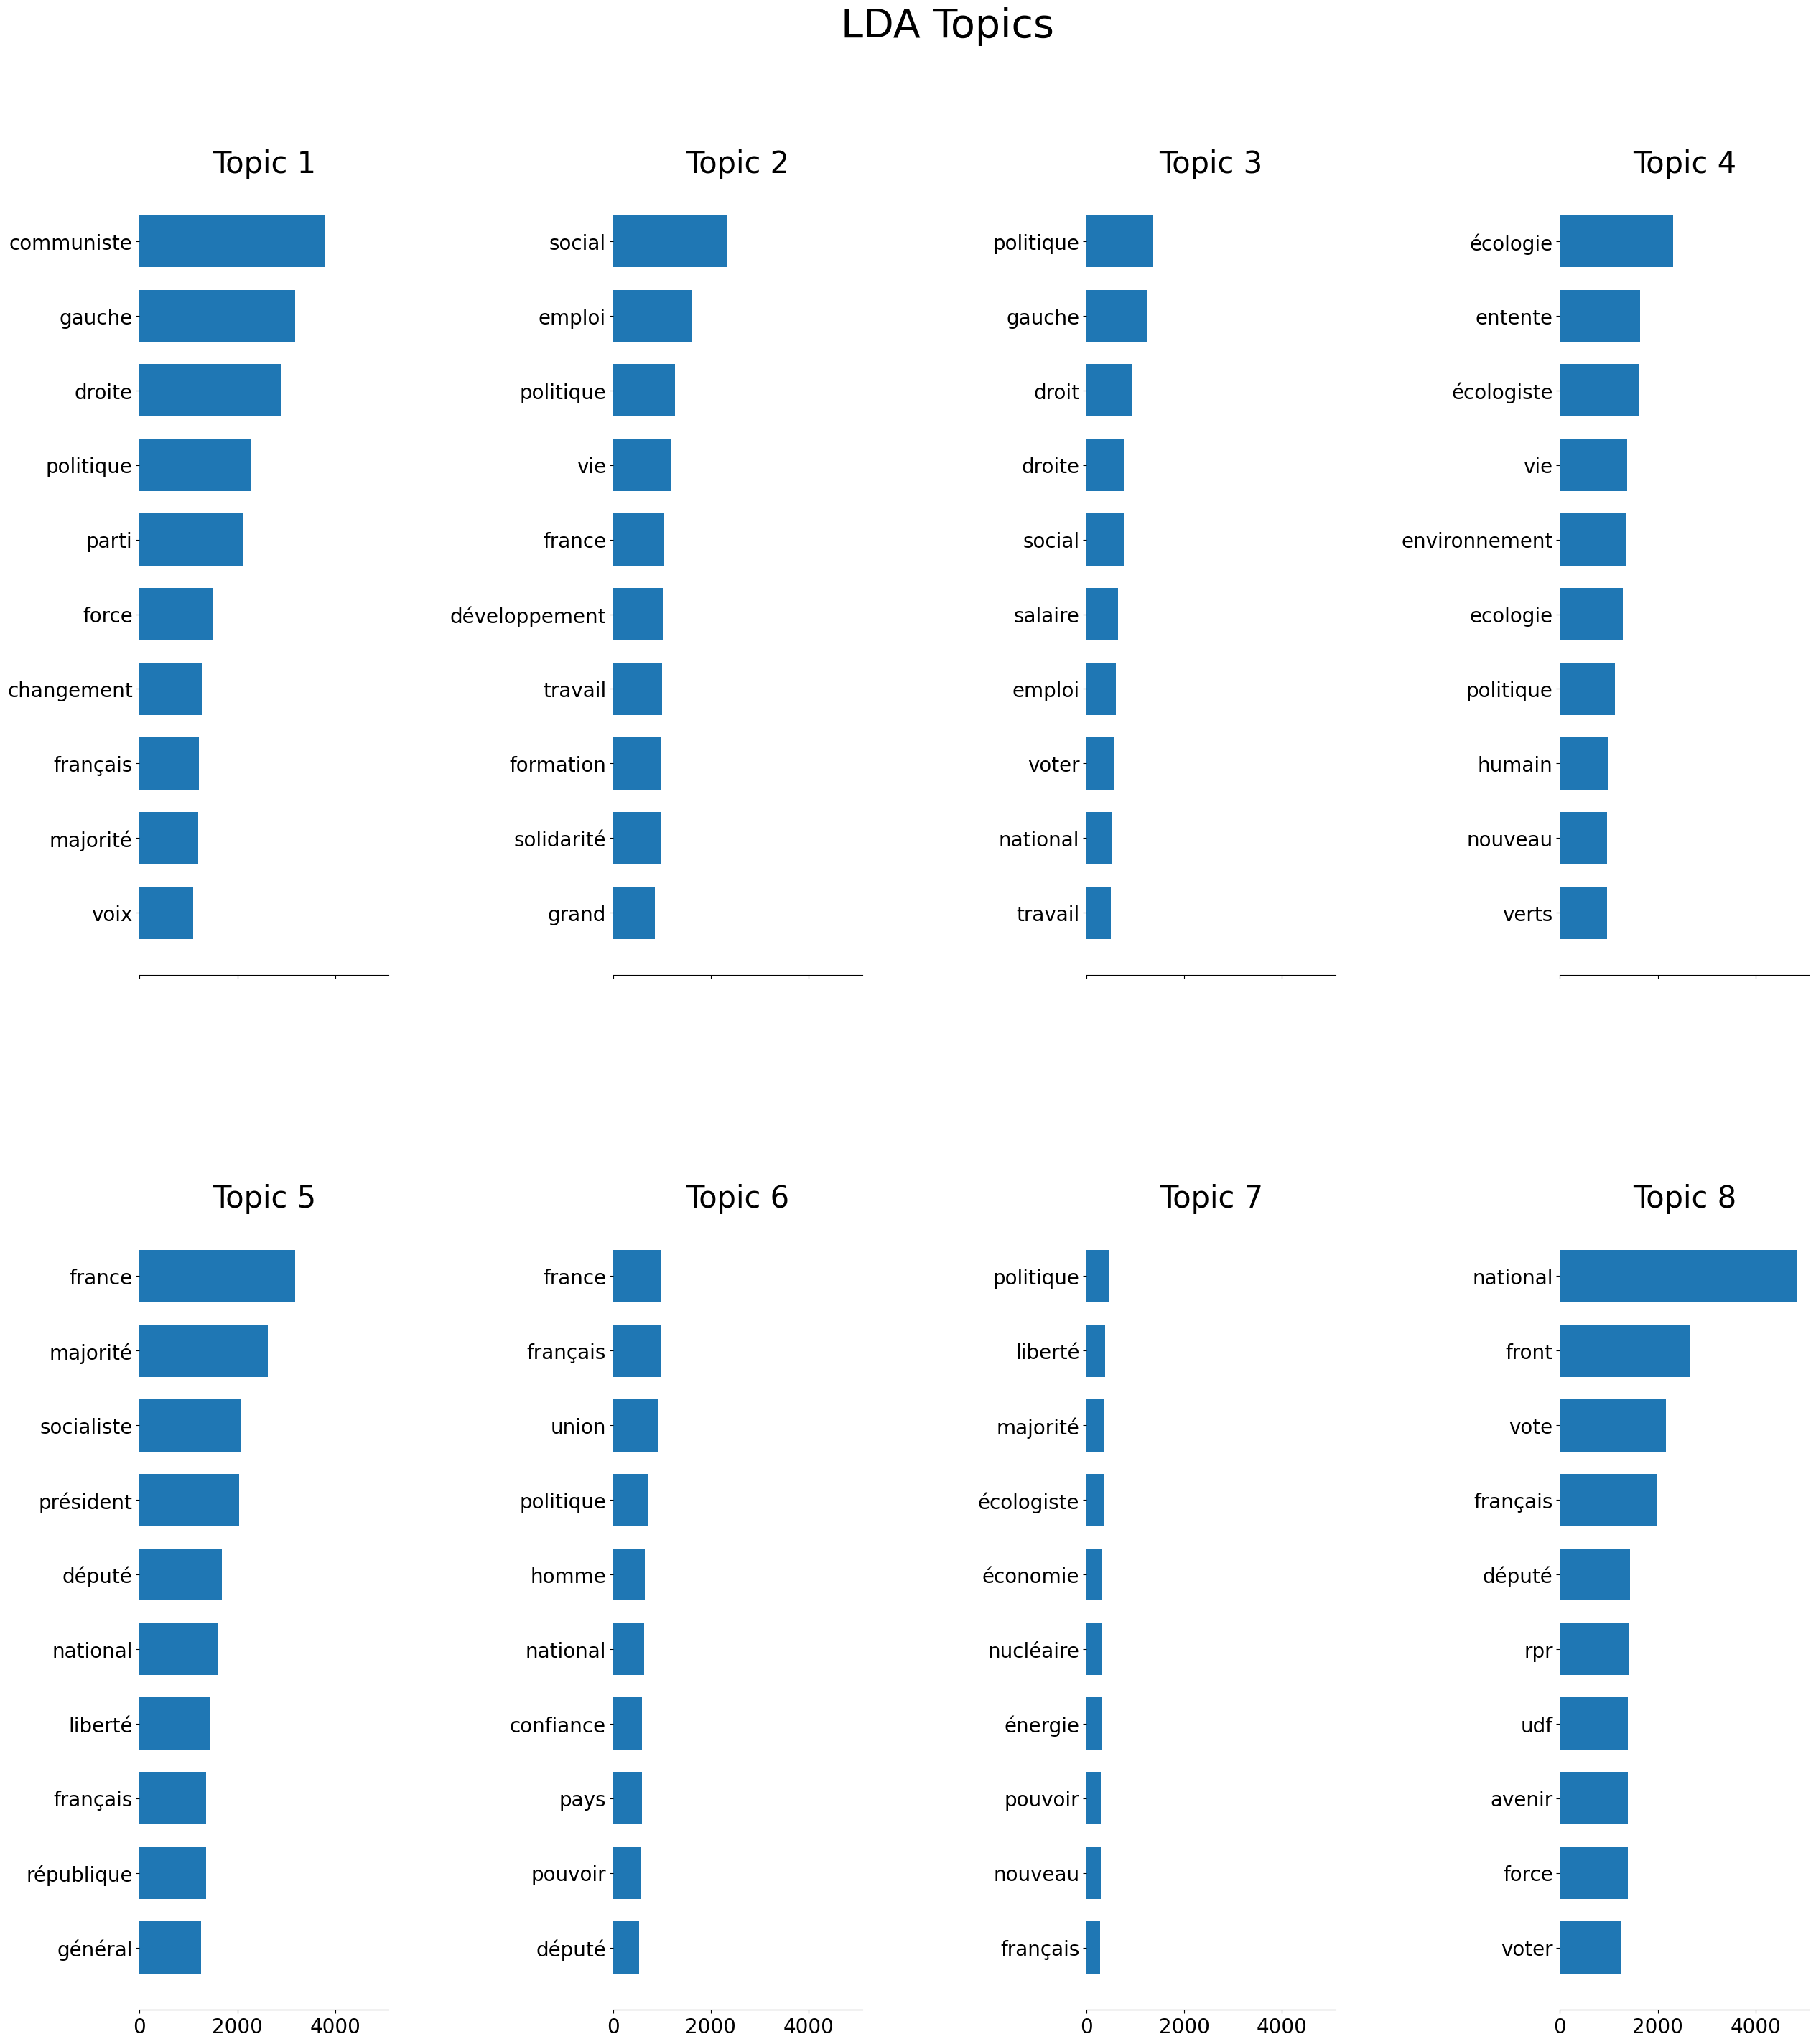

In [81]:
# visualize the words in topics
plot_top_words(lda, vectorizer, 10, "LDA Topics")

In [82]:
# PyLDAvis
import pyLDAvis
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()

pyLDAvis.lda_model.prepare(lda, X, vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.003084  0.078266       1        1  20.578252
1     -0.096691  0.036918       2        1  18.893399
0     -0.017174  0.101168       3        1  16.168127
7      0.362892 -0.063728       4        1  10.849536
3     -0.135256 -0.057158       5        1  10.663946
2     -0.064752 -0.019208       6        1   9.486844
5      0.029858  0.115963       7        1   8.052785
6     -0.081961 -0.192222       8        1   5.307111, topic_info=            Term         Freq        Total Category  logprob  loglift
2241    national  9328.000000  9328.000000  Default  30.0000  30.0000
661   communiste  4242.000000  4242.000000  Default  29.0000  29.0000
1472       front  2757.000000  2757.000000  Default  28.0000  28.0000
3724    écologie  2575.000000  2575.000000  Default  27.0000  27.0000
1508      gauche  4968.000000  4968.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
3631       vivre   146.152232  1457.597442   Topic8  -5.7655   0.6362
3597         vie   166.811440  4344.933534   Topic8  -5.6333  -0.3238
3724    écologie   152.863212  2575.031838   Topic8  -5.7206   0.1120
3007      région   144.690744  1667.187737   Topic8  -5.7755   0.4918
2241    national   144.541952  9328.470189   Topic8  -5.7766  -1.2311

[678 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
9         1  0.038319      aborder
9         2  0.045983      aborder
9         3  0.038319      aborder
9         5  0.850680      aborder
9         7  0.022991      aborder
...     ...       ...          ...
3780      6  0.127850      énergie
3780      7  0.049246      énergie
3780      8  0.279375      énergie
3787      1  0.976596    épargnant
3808      1  0.990367  étatisation

[2174 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 2, 1, 8, 4, 3, 6, 7])

### Document/Topic analysis

In [83]:
# Topic labels based on top words and manual interpretation
topic_label = {
    0: "Ideological Competition (Left vs Right)",
    1: "Social Policy and Welfare",
    2: "Labour and Economic Conflict",
    3: "Environmental Politics",
    4: "Presidential and Institutional Politics",
    5: "National Political Rhetoric",
    6: "Energy and Economic Policy",
    7: "Right-Wing Electoral Parties"
}

In [84]:
# Normalize the W matrix
W = lda.fit_transform(X)
W_norm = W / np.sum(W, axis=1, keepdims=True)

# dominant topic and topic score
df_cleaned["dominant_topic"] = np.argmax(W_norm, axis=1) 
df_cleaned["topic_score"] = np.max(W_norm, axis=1) 

df_cleaned["topic_label"] = df_cleaned["dominant_topic"].map(topic_label)
df_cleaned.head()

,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count,year,profession_clean,party_clean,text_lemma,dominant_topic,topic_score,topic_label
0,EL134_L_1981_06_001_03_1_PF_02,1981-06-14,Union de la gauche,agent SNCF,35,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,900,1981,Other,Other,science po fonds cevipof république français l...,0,0.830786,Ideological Competition (Left vs Right)
1,EL134_L_1981_06_001_03_1_PF_03,1981-06-14,Union pour une nouvelle majorité,docteur-vétérinaire,42,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...,607,1981,Health,Union pour une nouvelle majorité,science po fonds cevipof Jean VIAL an docteur ...,4,0.767548,Presidential and Institutional Politics
2,EL134_L_1981_06_001_03_1_PF_04,1981-06-14,Union pour une nouvelle majorité,médecin campagne,61,homme,01 - Ain,REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...,996,1981,Health,Union pour une nouvelle majorité,republique français troisieme circonscription ...,4,0.819093,Presidential and Institutional Politics
3,EL134_L_1981_06_002_01_1_PF_01,1981-06-14,Union pour réussir le changement,professeur,non mentionné,homme,02 - Aisne,ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...,342,1981,Education,Other,élection législatif juin circonscription AISNE...,0,0.588082,Ideological Competition (Left vs Right)
4,EL134_L_1981_06_002_02_1_PF_02,1981-06-14,Union pour une nouvelle majorité,vétérinaire,56,homme,02 - Aisne,Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...,497,1981,Other,Union pour une nouvelle majorité,science po fonds cevipof Lucien BOCHARD electi...,4,0.763698,Presidential and Institutional Politics



Document 1871
Dominant topic: 7 - Right-Wing Electoral Parties (0.996)

7raisons de voter pour le candidat du Front National Sciences Po / fonds CEVIPOF Commerçant-
Exportateur Chevalier du Mérite Agricole Président du Syndicat Départemental des Négociants en
bestiaux Président de la Coopérative Laitière de Bonneville Si vous voulez un député · qui soit
présent à l'Assemblée nationale et qui remplisse effectivement le mandat pour lequel les
contribuables le payent, comme les députés du Front National l'ont fait jusqu'ici à la différence de
leurs collègues des autres groupes presque toujours absents ; · qui, une fois élu, ne s'entendra pas
avec les socia- listes contre le vœu de ses électeurs, comme s'apprêtent déjà à le faire les
centristes du RPR et de l'UDF : · qui se prononce clairement pour l'union de toutes les for- ces
antisocialistes ; · qui vote pour la préférence nationale, la priorité d'emploi pour les Français,
la suppression de la taxe professionnelle, la création du reven

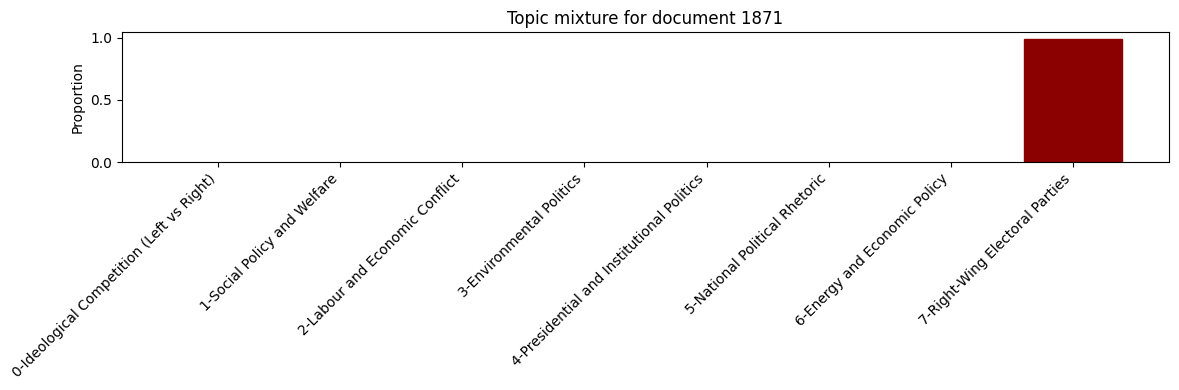


Document 2967
Dominant topic: 2 - Labour and Economic Conflict (0.998)

Sciences Po / fonds CEVIPOF alliance populaire CANDIDAT DE RASSEMBLEMENT DES FORCES NATIONALES %
RÉPUBLIQUE FRANÇAISE ÉLECTIONS DES 21 et 28 MARS 1993 6eme CIRCONSCRIPTION DE LA MOSELLE Candidat
Patrice SAINTY 47 ans - Agent commercial Suppléant Jean-René RATIER 44 ans - Agent technique Chers
Compatriotes, Comme après le passage d'une catastrophe naturelle, la France, après le passage du
socialisme est aujourd'hui un pays sinistré. En 12 ans, en effet, le socialo-mitterrandisme aura
mené notre pays au bord du gouffre : · 12 ans d'affairisme, de scandales et de contamination. · 12
ans de chômage, d'injustices et de récession sociales. · 12 ans de fiscalisme, de déficit et
d'asphyxie de notre économie. · 12 ans d'assassinat de notre paysannerie. · 12 ans d'abrutissement
culturel et d'échec scolaire. · 12 ans de lâcheté, d'abandon et d'humiliation. PAR VOTRE VOTE Les 21
et 28 MARS prochains, vous allez ... vous devez

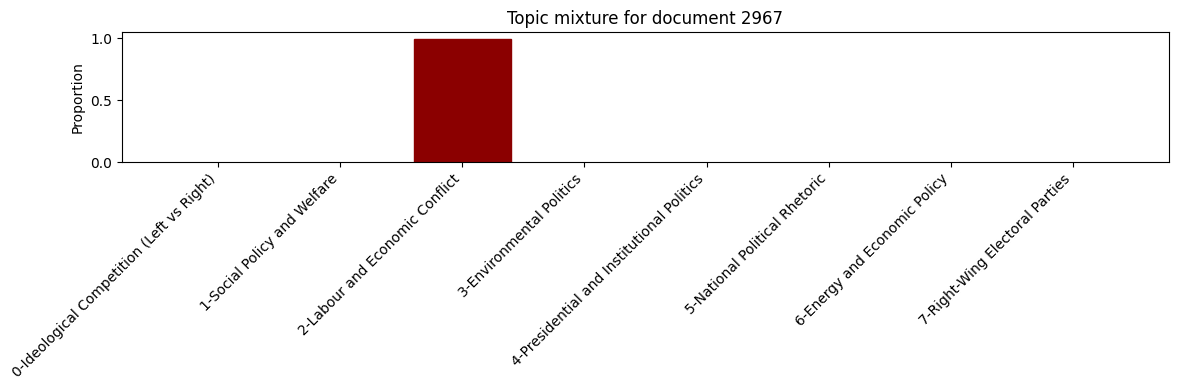


Document 3206
Dominant topic: 2 - Labour and Economic Conflict (0.770)

Sciences Po / fonds CEVIPOF Elections législatives du 21 mars 1993 - 3e circonscription de Seine-
Maritime VRAIMENT / Michèle ERNIS Je m'appelle Michèle ERNIS, je suis institutrice, en poste à
Sotteville puis à Saint Etienne du Rouvray où j'habite. Conseillère municipale depuis 10 ans,
militante de la LCR, beaucoup connaissent mon engagement contre les licenciements, aux côtés des
travailleurs de la Chapelle, de la Sagem, ou de Sopalin ... Alors que ce n'était pas encore à la
mode, je me suis battue contre les dépôts de Phosphogypse, pour défendre la forêt du Rouvray. Depuis
des années, je suis attachée aux droits des femmes, je défends l'accueil de la petite enfance.
Révoltée par le racisme, je pense que les étrangers qui vivent parmi nous doivent avoir le droit de
voter. Militante syndicale, je m'attache à défendre l'Ecole publique! Philippe COCAGNE Je m'appelle
Philippe COCAGNE. J'habite Petit-Quevilly et je su

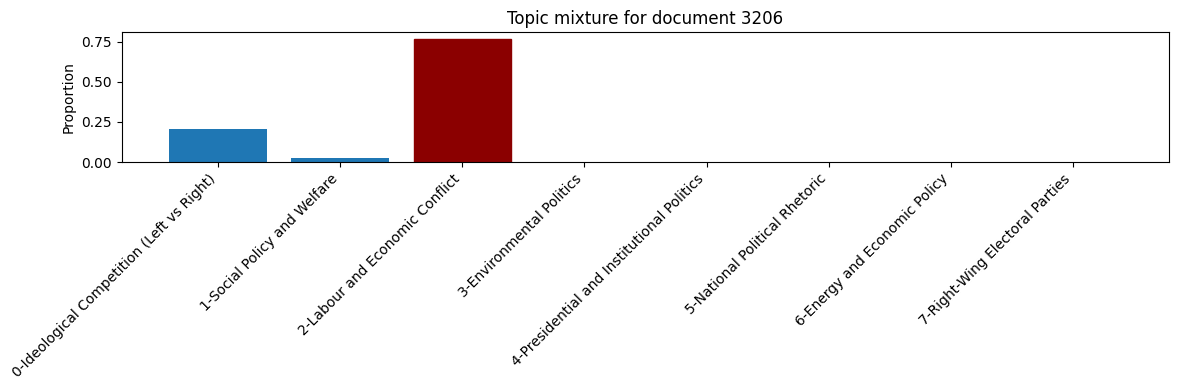


Document 496
Dominant topic: 4 - Presidential and Institutional Politics (0.617)

Sciences Po / fonds CEVIPOF Albert ROLLET SUPPLÉANT Marié - 3 Enfants Responsable du Service
Formation de la Chambre d'Agriculture Maire de Savigny Conseiller Gal du Canton de l'Arbresle
Conseiller Régional Rhône-Alpes RÉPUBLIQUE FRANÇAISE - DÉPARTEMENT DU RHONE - 8me CIRCONSCRIPTION -
ÉLECTIONS LÉGISLATIVES du 14 JUIN 1981 EMMANUEL HAMEL Marié - 2 Enfants - Conseiller Municipal de
Vaugneray Chevalier de la Légion d'Honneur - Croix de Guerre 1944-1945 - Chevalier du Mérite
National - Docteur es-sciences économiques (1952) - Diplômé d'Études Supérieures de droit -
Conseiller à la Cour des Comptes (1957-1973) - Député du Rhône (1973-1981) Membre du Bureau de
l'Assemblée Nationale (1980-81) CANDIDAT UNIQUE DE l'Union pour une Nouvelle Majorité Madame,
Mademoiselle, Monsieur La sympathie et même l'amitié de beaucoup d'entre vous, jeunes ou anciens,
heureux ou brisés par les souffrances de la vie, pauvres ou 

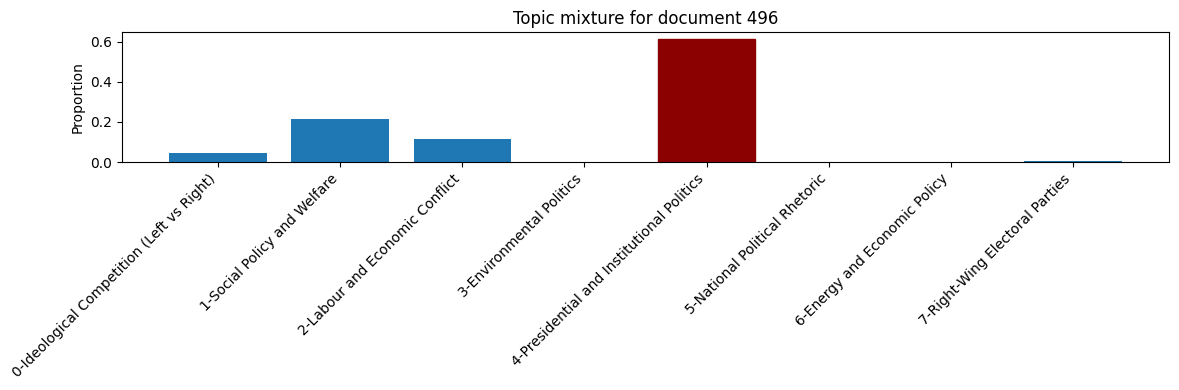


Document 2329
Dominant topic: 4 - Presidential and Institutional Politics (0.584)

Sciences Po / fonds CEVIPOF ÉLECTION LÉGISLATIVE DU 12 JUIN 1988 - RÉPUBLIQUE FRANÇAISE 3e
CIRCONSCRIPTION DE LA DRÔME Hervé Mariton, Conseiller régional, est âgé de 30 ans. Ancien élève de
l'Ecole Polytechnique, Hervé Mariton est ingénieur au Ministère de l'Industrie et de l'Aménagement
du Territoire. HERVÉ MARITON Conseiller régional de la Drôme Candidat de l'Union pour le
Rassemblement et le Centre JACQUES PERRIN suppléant Jacques Perrin, 40 ans, est directeur de la
Chambre de Commerce et d'Industrie à Nyons. Originaire de St- Nazaire le Désert, il connaît
particulièrement le Diois et est déterminé, avec Hervé Mariton, à aider l'arrière- pays à reprendre
confiance en ses capacités et en ses chances. Chères électrices, chers électeurs, JE VOUDRAIS
D'ABORD VOUS DIRE : MERCI Dimanche dernier, vous avez refusé votre soutien au candidat sortant.
Grâce à vous, je représente désormais l'ensemble de ceux qui

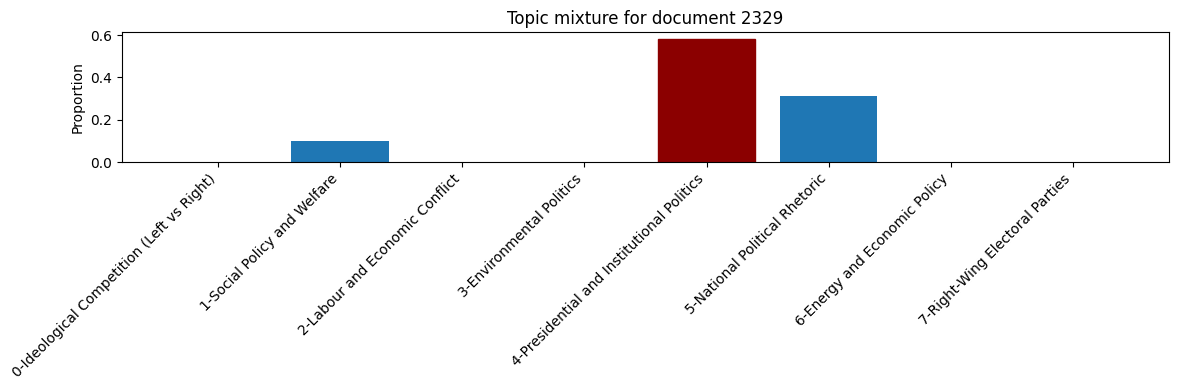

In [85]:
import textwrap

topic_names = [f"{k}-{topic_label[k]}" for k in topic_label.keys()]

# Sample documents
sample_ids = df_cleaned.sample(n=5, random_state=2026).index

for doc_id in sample_ids:

    topic_distribution = W_norm[doc_id]

    dominant_topic = df_cleaned.loc[doc_id, "dominant_topic"]
    dominant_score = df_cleaned.loc[doc_id, "topic_score"]
    dominant_label = topic_label[dominant_topic]

    print(f"\nDocument {doc_id}")
    print(f"Dominant topic: {dominant_topic} - {dominant_label} ({dominant_score:.3f})\n")

    text = textwrap.fill(df_cleaned.loc[doc_id, "text"], width=100)
    print(text[:1200])
    print("\n\n")

    # Plot topic distribution   
    plt.figure(figsize=(12,4))
    bars = plt.bar(topic_names, topic_distribution)

    bars[dominant_topic].set_color("darkred")

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Proportion")
    plt.title(f"Topic mixture for document {doc_id}")
    plt.tight_layout()
    plt.show()

### Topic modeling with embeddings : Bertopic

In [86]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

# Define custom stopwords for BERTopic
vectorizer_model = CountVectorizer( 
    stop_words=all_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',
    max_df=0.9,
    min_df=2
)

# Load multilingual sentence transformer model
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Initialize BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

# Prepare documents for BERTopic
docs = df_cleaned["text"].astype(str).tolist()

# Fit BERTopic model
topics, probs = topic_model.fit_transform(docs)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9062.02it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-04 02:18:38,398 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 113/113 [00:20<00:00,  5.58it/s]
2026-04-04 02:18:58,879 - BERTopic - Embedding - Completed ✓
2026-04-04 02:18:58,879 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 02:19:05,853 - BERTopic - Dimensionality - Completed ✓
2026-04-04 02:19:05,854 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 02:19:06,109 - BERTopic - Cluster - Completed ✓
2026-04-04 02:19:06,112 - BERTopic - Representation - Fine-tuning topics 

In [87]:
# Get topic information
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1459,-1_majorité_communiste_changement_ensemble,"[majorité, communiste, changement, ensemble, g...",[Sciences Po / fonds CEVIPOF\nRépublique Franç...
1,0,466,0_écologie_ecologistes_entente_verts,"[écologie, ecologistes, entente, verts, écolog...",[Sciences Po / fonds CEVIPOF\nENTENTE DES ECOL...
2,1,332,1_front_rpr_udf_convictions,"[front, rpr, udf, convictions, vive, jusqu, ic...",[7 raisons de voter pour le candidat du Front ...
3,2,309,2_majorité_changement_ensemble_doit,"[majorité, changement, ensemble, doit, général...",[Sciences Po / fonds CEVIPOF\n4e circonscripti...
4,3,68,3_majorité_doit_droit_changement,"[majorité, doit, droit, changement, droits, mo...",[ELECTIONS LEGISLATIVES du 14 JUIN 1981\ngeme ...
5,4,51,4_majorité_communistes_communiste_garantir,"[majorité, communistes, communiste, garantir, ...",[Sciences Po / fonds CEVIPOF\nÉLECTIONS LÉGISL...
6,5,50,5_communiste_ouverture_général_département,"[communiste, ouverture, général, département, ...",[DEPARTEMENT DE LA VENDEE\nSCRUTIN DU 5 JUIN 1...
7,6,49,6_front_rpr_udf_vive,"[front, rpr, udf, vive, convictions, jusqu, po...",[Sciences Po / fonds CEVIPOF\nMaintenant la fo...
8,7,45,7_unie_majorité_presidentielle_solidarité,"[unie, majorité, presidentielle, solidarité, p...",[Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\n...
9,8,41,8_egalité_bouches_fraternité_marseille,"[egalité, bouches, fraternité, marseille, majo...",[Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇ...


In [88]:
topic_model.get_topic(0)

[('écologie', np.float64(0.031552225274365256)),
 ('ecologistes', np.float64(0.02598552862575877)),
 ('entente', np.float64(0.024559570360132423)),
 ('verts', np.float64(0.023497234112275757)),
 ('écologistes', np.float64(0.022588365149899797)),
 ('ecologie', np.float64(0.02153974841907403)),
 ('environnement', np.float64(0.020042963548550473)),
 ('generation', np.float64(0.015119969473940547)),
 ('peu', np.float64(0.014415144220528827)),
 ('chance', np.float64(0.013637452483834191))]

In [89]:
topic_model.visualize_barchart()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': '#D55E00'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.022588365149899797, 0.023497234112275757,
                    0.024559570360132423, 0.02598552862575877,
                    0.031552225274365256],
              'xaxis': 'x',
              'y': [écologistes  , verts  , entente  , ecologistes  , écologie  ],
              'yaxis': 'y'},
             {'marker': {'color': '#0072B2'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.03309889521996754, 0.03352225383520029,
                    0.039653923383989716, 0.04014643606657974, 0.0620547485504753],
              'xaxis': 'x2',
              'y': [vive  , convictions  , udf  , rpr  , front  ],
              'yaxis': 'y2'},
             {'marker': {'color': '#CC79A7'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.007032906266487752, 0.00734568881585677,
                    0.007947393271431647, 0.00798795145100443,
                    0.013775337561182672],
              'xaxis': 'x3',
              'y': [général  , doit  , ensemble  , changement  , majorité  ],
              'yaxis': 'y3'},
             {'marker': {'color': '#E69F00'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.008053654561651113, 0.008529620462801818,
                    0.00930322697285354, 0.009415636018122411,
                    0.009738899739095305],
              'xaxis': 'x4',
              'y': [droits  , changement  , droit  , doit  , majorité  ],
              'yaxis': 'y4'},
             {'marker': {'color': '#56B4E9'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.015060086584912306, 0.015167457983854963,
                    0.015399028013373483, 0.01811072297481908,
                    0.021457065044744875],
              'xaxis': 'x5',
              'y': [nantes  , garantir  , communiste  , communistes  , majorité  ],
              'yaxis': 'y5'},
             {'marker': {'color': '#009E73'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.008553727203298635, 0.009014779426730886,
                    0.009180630692495001, 0.01030933859485766,
                    0.011282353844551158],
              'xaxis': 'x6',
              'y': [rassemblement  , département  , général  , ouverture  ,
                    communiste  ],
              'yaxis': 'y6'},
             {'marker': {'color': '#F0E442'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.02561590071521591, 0.03328986150908215, 0.04004751393047172,
                    0.040924980110157064, 0.06526362452830298],
              'xaxis': 'x7',
              'y': [convictions  , vive  , udf  , rpr  , front  ],
              'yaxis': 'y7'},
             {'marker': {'color': '#D55E00'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.013998934386507329, 0.015469001775393289,
                    0.01597313951570254, 0.021863962176117996,
                    0.037349027020221165],
              'xaxis': 'x8',
              'y': [présidentielle  , solidarité  , presidentielle  , majorité  ,
                    unie  ],
              'yaxis': 'y8'}],
    'layout': {'annotations': [{'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Topic 0',
                                'x': 0.0875,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Topic 1',
                                'x': 0.3625000000000000

### Topic numbers analysis


In [90]:
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from sklearn.decomposition import NMF

# Tokenization
analyzer = vectorizer.build_analyzer()

tokenized_texts = [
    analyzer(doc)
    for doc in df_cleaned["text_lemma"]
]

# Create dictionary for coherence
dictionary = Dictionary(tokenized_texts)

# Optional but useful
dictionary.filter_extremes(no_below=5, no_above=0.95)

In [91]:
# Helper function to extract topics
def get_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic in model.components_:
        top_indices = np.argsort(-topic)[:n_top_words]
        topics.append([feature_names[i] for i in top_indices])
    return topics

In [92]:
feature_names = vectorizer.get_feature_names_out()

# Topic numbers to evaluate
topic_range = [5, 10, 15, 20, 25, 30]

coherence_metrics = ['u_mass', 'c_v', 'c_uci', 'c_npmi']

results = {metric: {} for metric in coherence_metrics}

# Run coherence evaluation
for k in topic_range:

    lda_model = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method="batch"
    )

    lda_model.fit(X)

    topics = get_topics(lda_model, feature_names, 10)

    for metric in coherence_metrics:

        coherence_model = CoherenceModel(
            topics=topics,
            texts=tokenized_texts,
            dictionary=dictionary,
            coherence=metric
        )

        coherence_score = coherence_model.get_coherence()

        results[metric][k] = coherence_score

        print(f"LDA coherence | topics={k} | metric={metric}: {coherence_score:.4f}")

LDA coherence | topics=5 | metric=u_mass: -0.5198
LDA coherence | topics=5 | metric=c_v: 0.6004
LDA coherence | topics=5 | metric=c_uci: 0.3896
LDA coherence | topics=5 | metric=c_npmi: 0.0825
LDA coherence | topics=10 | metric=u_mass: -0.6348
LDA coherence | topics=10 | metric=c_v: 0.5619
LDA coherence | topics=10 | metric=c_uci: 0.3173
LDA coherence | topics=10 | metric=c_npmi: 0.0683
LDA coherence | topics=15 | metric=u_mass: -0.6879
LDA coherence | topics=15 | metric=c_v: 0.5582
LDA coherence | topics=15 | metric=c_uci: 0.2617
LDA coherence | topics=15 | metric=c_npmi: 0.0598
LDA coherence | topics=20 | metric=u_mass: -0.7669
LDA coherence | topics=20 | metric=c_v: 0.5477
LDA coherence | topics=20 | metric=c_uci: 0.0370
LDA coherence | topics=20 | metric=c_npmi: 0.0504
LDA coherence | topics=25 | metric=u_mass: -0.8933
LDA coherence | topics=25 | metric=c_v: 0.5355
LDA coherence | topics=25 | metric=c_uci: -0.0609
LDA coherence | topics=25 | metric=c_npmi: 0.0419
LDA coherence | to

In [93]:
import pandas as pd

metric_results = pd.DataFrame(results)
metric_results

,u_mass,c_v,c_uci,c_npmi
5,-0.519776,0.600448,0.389610,0.082528
10,-0.634772,0.561905,0.317305,0.068256
15,-0.687906,0.558227,0.261748,0.059827
20,-0.766936,0.547661,0.036953,0.050416
25,-0.893342,0.535531,-0.060888,0.041879
30,-0.902569,0.519264,-0.093988,0.041626


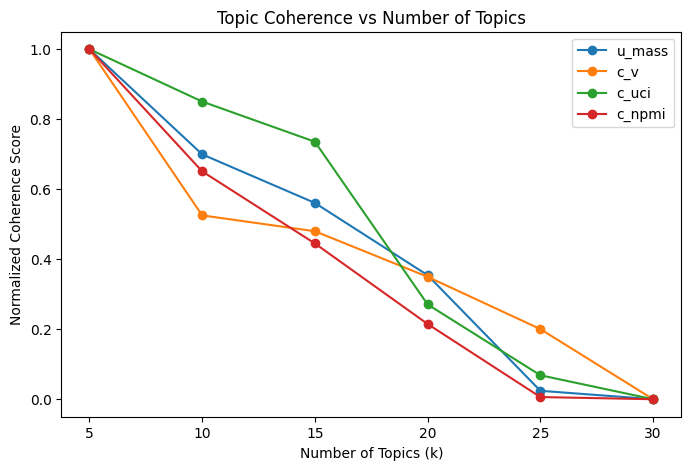

In [94]:
normalized = (metric_results - metric_results.min()) / (metric_results.max() - metric_results.min())
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for metric in coherence_metrics:
    plt.plot(topic_range, normalized[metric], marker='o', label=metric)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Normalized Coherence Score")
plt.title("Topic Coherence vs Number of Topics")
plt.legend()
plt.show()

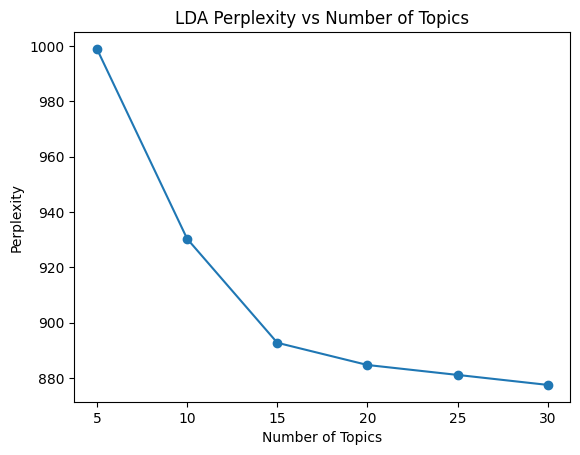

In [95]:
from sklearn.decomposition import LatentDirichletAllocation

lda_models = {}
perplexities = []

for k in topic_range:
    
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method='batch'
    )
    
    lda.fit(X)
    
    lda_models[k] = lda
    
    perplexities.append(lda.perplexity(X))


plt.plot(topic_range, perplexities, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Perplexity")
plt.title("LDA Perplexity vs Number of Topics")
plt.show()

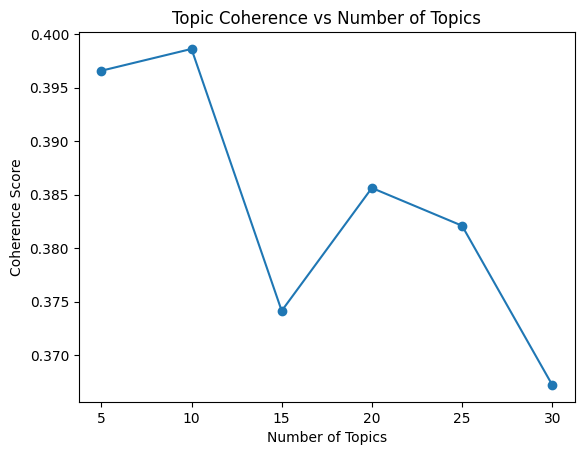

In [96]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

texts = [
    doc.split()
    for doc in df_cleaned['text']
]

dictionary = Dictionary(texts)

coherence_scores = []

for k in topic_range:
    
    lda_model = lda_models[k]
    
    topics = [
        [words[i] for i in topic.argsort()[-10:]]
        for topic in lda_model.components_
    ]
    
    coherence_model = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    coherence_scores.append(coherence_model.get_coherence())

plt.plot(topic_range, coherence_scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Topic Coherence vs Number of Topics")
plt.show()

### Final LDA with best number of topics

In [97]:
from sklearn.decomposition import LatentDirichletAllocation

lda_final = LatentDirichletAllocation(
    n_components=10, # based on coherence and perplexity analysis
    random_state=42,
    learning_method='batch'
)

lda_final.fit(X)

# show top words for topic
print_topics(lda_final, words)

Topic 0: ['droite', 'communiste', 'gauche', 'politique', 'parti', 'force', 'avoir', 'français', 'pouvoir', 'social']
Topic 1: ['social', 'france', 'emploi', 'formation', 'solidarité', 'français', 'développement', 'vie', 'unie', 'national']
Topic 2: ['politique', 'gauche', 'droit', 'social', 'emploi', 'droite', 'travail', 'salaire', 'pouvoir', 'non']
Topic 3: ['communiste', 'majorité', 'changement', 'gauche', 'parti', 'victoire', 'union', 'réussir', 'nouveau', 'gouvernement']
Topic 4: ['national', 'france', 'député', 'général', 'président', 'union', 'liberté', 'politique', 'majorité', 'français']
Topic 5: ['politique', 'union', 'homme', 'français', 'france', 'pouvoir', 'député', 'confiance', 'national', 'pays']
Topic 6: ['liberté', 'politique', 'français', 'majorité', 'france', 'économie', 'national', 'écologiste', 'nucléaire', 'nouveau']
Topic 7: ['france', 'socialiste', 'majorité', 'parti', 'françois', 'président', 'mitterrand', 'français', 'république', 'ensemble']
Topic 8: ['nationa

In [98]:
doc_topic = lda_final.transform(X) # document-topic distribution
topic_columns = [f"Topic_{i}" for i in range(10)]

topic_df = pd.DataFrame(doc_topic, columns=topic_columns)
topic_df.head()

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
0,0.000293,0.000293,0.000293,0.851032,0.000293,0.100610,0.000293,0.046306,0.000293,0.000293
1,0.000410,0.000410,0.000410,0.000410,0.996310,0.000410,0.000410,0.000410,0.000410,0.000410
2,0.000321,0.000321,0.000321,0.000321,0.997115,0.000321,0.000321,0.000321,0.000321,0.000321
3,0.000764,0.000764,0.215010,0.533015,0.246629,0.000764,0.000763,0.000764,0.000764,0.000764
4,0.054786,0.000658,0.000658,0.000658,0.863194,0.077413,0.000658,0.000658,0.000658,0.000658


In [99]:
# join topic distribution with original dataframe
df_topics = pd.concat(
    [df_cleaned.reset_index(drop=True), topic_df],
    axis=1
)

df_topics.head()

,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count,year,...,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
0,EL134_L_1981_06_001_03_1_PF_02,1981-06-14,Union de la gauche,agent SNCF,35,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,900,1981,...,0.000293,0.000293,0.000293,0.851032,0.000293,0.100610,0.000293,0.046306,0.000293,0.000293
1,EL134_L_1981_06_001_03_1_PF_03,1981-06-14,Union pour une nouvelle majorité,docteur-vétérinaire,42,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...,607,1981,...,0.000410,0.000410,0.000410,0.000410,0.996310,0.000410,0.000410,0.000410,0.000410,0.000410
2,EL134_L_1981_06_001_03_1_PF_04,1981-06-14,Union pour une nouvelle majorité,médecin campagne,61,homme,01 - Ain,REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...,996,1981,...,0.000321,0.000321,0.000321,0.000321,0.997115,0.000321,0.000321,0.000321,0.000321,0.000321
3,EL134_L_1981_06_002_01_1_PF_01,1981-06-14,Union pour réussir le changement,professeur,non mentionné,homme,02 - Aisne,ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...,342,1981,...,0.000764,0.000764,0.215010,0.533015,0.246629,0.000764,0.000763,0.000764,0.000764,0.000764
4,EL134_L_1981_06_002_02_1_PF_02,1981-06-14,Union pour une nouvelle majorité,vétérinaire,56,homme,02 - Aisne,Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...,497,1981,...,0.054786,0.000658,0.000658,0.000658,0.863194,0.077413,0.000658,0.000658,0.000658,0.000658


In [100]:
df_topics[[f"Topic_{i}" for i in range(10)]].mean().sort_values(ascending=False)

Topic_4    0.178810
Topic_8    0.126470
Topic_1    0.117443
Topic_5    0.110314
Topic_9    0.105694
Topic_2    0.095481
Topic_7    0.093460
Topic_0    0.085148
Topic_3    0.055107
Topic_6    0.032073
dtype: float64

In [101]:
# save data
df_topics.to_csv("../data/processed/data_topics.csv", index=False)